
# EDA: KAERI TR-1665 — Uniformly Heated Tubes (`kaeri_tr1665_uniform_chf.csv`)

CHF test data for uniformly (axially) heated round tubes from KAERI/TR-1665
(Swenson-type dataset). A parallel `kaeri_tr1665_uniform.xml` file carries the
same records in XML form; a cross-check is included below.

## 1. Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../../data/raw/external")
OUT_DIR = Path("../../results/eda/kaeri_tr1665_uniform")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

SLUG = "kaeri_tr1665_uniform"
SLUG_TITLE = "KAERI TR-1665 Uniform Heating"

df = pd.read_csv(DATA_DIR / "kaeri_tr1665_uniform_chf.csv")

NUMERIC_COLS = ["Diameter", "Perimeter", "Area", "Length", "Pressure", "Power",
                "MassFlux", "MassFlow", "EquilibriumQuality", "InletTemperature",
                "InletEnthalpy", "HeatFlux", "WallMesh"]
CATEGORICAL_COLS = ["Fluid", "Source"]
TARGET_COL = "HeatFlux"

df.head()

,TestID,Diameter,Perimeter,Area,Length,Pressure,Power,MassFlux,MassFlow,EquilibriumQuality,InletTemperature,InletEnthalpy,HeatFlux,Fluid,Source,WallPower,WallMesh
0,1,0.01044,0.0328,0.000086,1.83,13790000.0,35220.18,678.1,0.0580,0.511,328.438,1510619.23,586800,water,Swenson,1,0.915
1,2,0.01044,0.0328,0.000086,1.83,13790000.0,40333.95,949.4,0.0813,0.401,327.027,1501019.23,672000,water,Swenson,1,0.915
2,3,0.01044,0.0328,0.000086,1.83,13790000.0,45639.78,1356.3,0.1161,0.320,329.236,1516119.23,760400,water,Swenson,1,0.915
3,4,0.01044,0.0328,0.000086,1.83,13790000.0,49427.09,1763.2,0.1509,0.261,329.538,1518219.23,823500,water,Swenson,1,0.915
4,5,0.01044,0.0328,0.000086,1.83,13790000.0,55861.32,1763.2,0.1509,0.234,318.598,1446619.23,930700,water,Swenson,1,0.915


## 1b. Cross-check against `kaeri_tr1665_uniform.xml`

In [2]:
import xml.etree.ElementTree as ET

tree = ET.parse(DATA_DIR / "kaeri_tr1665_uniform.xml")
records = []
for ds in tree.getroot().findall("dataset"):
    rec = {}
    for child in ds:
        rec.setdefault(child.tag, []).append(child.text)
    records.append(rec)

# Flag fields that repeat within a single <dataset> block (e.g. WallPower, WallMesh
# each appear twice in the raw XML) -- this is a structural quirk of the source file,
# not extra information.
repeated_fields = sorted({tag for rec in records for tag, vals in rec.items() if len(vals) > 1})
print("XML fields with duplicated tags per record:", repeated_fields)

df_xml = pd.DataFrame([{tag: vals[0] for tag, vals in rec.items()} for rec in records])
df_xml = df_xml.apply(pd.to_numeric, errors="ignore")

print("CSV rows:", len(df), " XML records:", len(df_xml))
print("Column sets match:", set(df.columns) == set(df_xml.columns))

XML fields with duplicated tags per record: ['WallMesh', 'WallPower']
CSV rows: 651  XML records: 651
Column sets match: True


/var/folders/ch/_7rmvz4j4ql8x688nwpycfkm0000gn/T/ipykernel_11932/901234853.py:18: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_xml = df_xml.apply(pd.to_numeric, errors="ignore")


## 2. Data Quality

In [3]:
print("Shape:", df.shape)
print()
print("Dtypes:")
print(df.dtypes)
print()
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing values per column:")
print(missing if len(missing) else "None")
print()
print("Duplicate rows:", df.duplicated().sum())

Shape: (651, 17)

Dtypes:
TestID                  int64
Diameter              float64
Perimeter             float64
Area                  float64
Length                float64
Pressure              float64
Power                 float64
MassFlux              float64
MassFlow              float64
EquilibriumQuality    float64
InletTemperature      float64
InletEnthalpy         float64
HeatFlux                int64
Fluid                  object
Source                 object
WallPower               int64
WallMesh              float64
dtype: object

Missing values per column:
None

Duplicate rows: 0


## 3. Descriptive Statistics

In [4]:
numeric_summary = df[NUMERIC_COLS].describe().T
numeric_summary.to_csv(OUT_DIR / "summary_stats.csv")
numeric_summary

,count,mean,std,min,25%,50%,75%,max
Diameter,651.0,1.207488e-02,5.908140e-03,0.005440,7.900000e-03,1.016000e-02,1.407000e-02,2.830000e-02
Perimeter,651.0,3.793364e-02,1.856559e-02,0.017100,2.480000e-02,3.190000e-02,4.420000e-02,8.890000e-02
Area,651.0,1.418860e-04,1.611093e-04,0.000023,4.901700e-05,8.107300e-05,1.554800e-04,6.290200e-04
Length,651.0,1.339869e+00,1.150037e+00,0.061300,5.000000e-01,9.900000e-01,1.730000e+00,4.880000e+00
Pressure,651.0,9.899724e+06,3.590843e+06,430000.000000,6.900000e+06,1.000000e+07,1.241000e+07,1.800000e+07
Power,651.0,9.805499e+04,7.306312e+04,1348.000000,4.142780e+04,8.181015e+04,1.397430e+05,5.292660e+05
MassFlux,651.0,2.025768e+03,1.179314e+03,335.000000,1.015900e+03,1.968000e+03,2.703100e+03,9.561900e+03
MassFlow,651.0,2.244129e-01,1.750146e-01,0.015100,7.680000e-02,1.584000e-01,3.157000e-01,8.753000e-01
EquilibriumQuality,651.0,1.935656e-01,2.156206e-01,-0.582000,5.200000e-02,1.920000e-01,3.380000e-01,9.010000e-01
InletTemperature,651.0,2.504855e+02,5.725298e+01,14.487000,2.313760e+02,2.676160e+02,2.850080e+02,3.411750e+02


## 4. Categorical Value Counts

In [5]:
for col in CATEGORICAL_COLS:
    print(f"--- {col} (n_unique={df[col].nunique(dropna=True)}) ---")
    print(df[col].value_counts(dropna=False).head(15))
    print()

--- Fluid (n_unique=1) ---
Fluid
water    651
Name: count, dtype: int64

--- Source (n_unique=10) ---
Source
Lee(1966)     222
Zenkevich     161
Lee(1965)     125
Bertoletti     64
Casterline     27
Swenson        25
Todreas        17
AEEW            5
Kinoshita       4
lee(1966)       1
Name: count, dtype: int64



## 5. Univariate Distributions

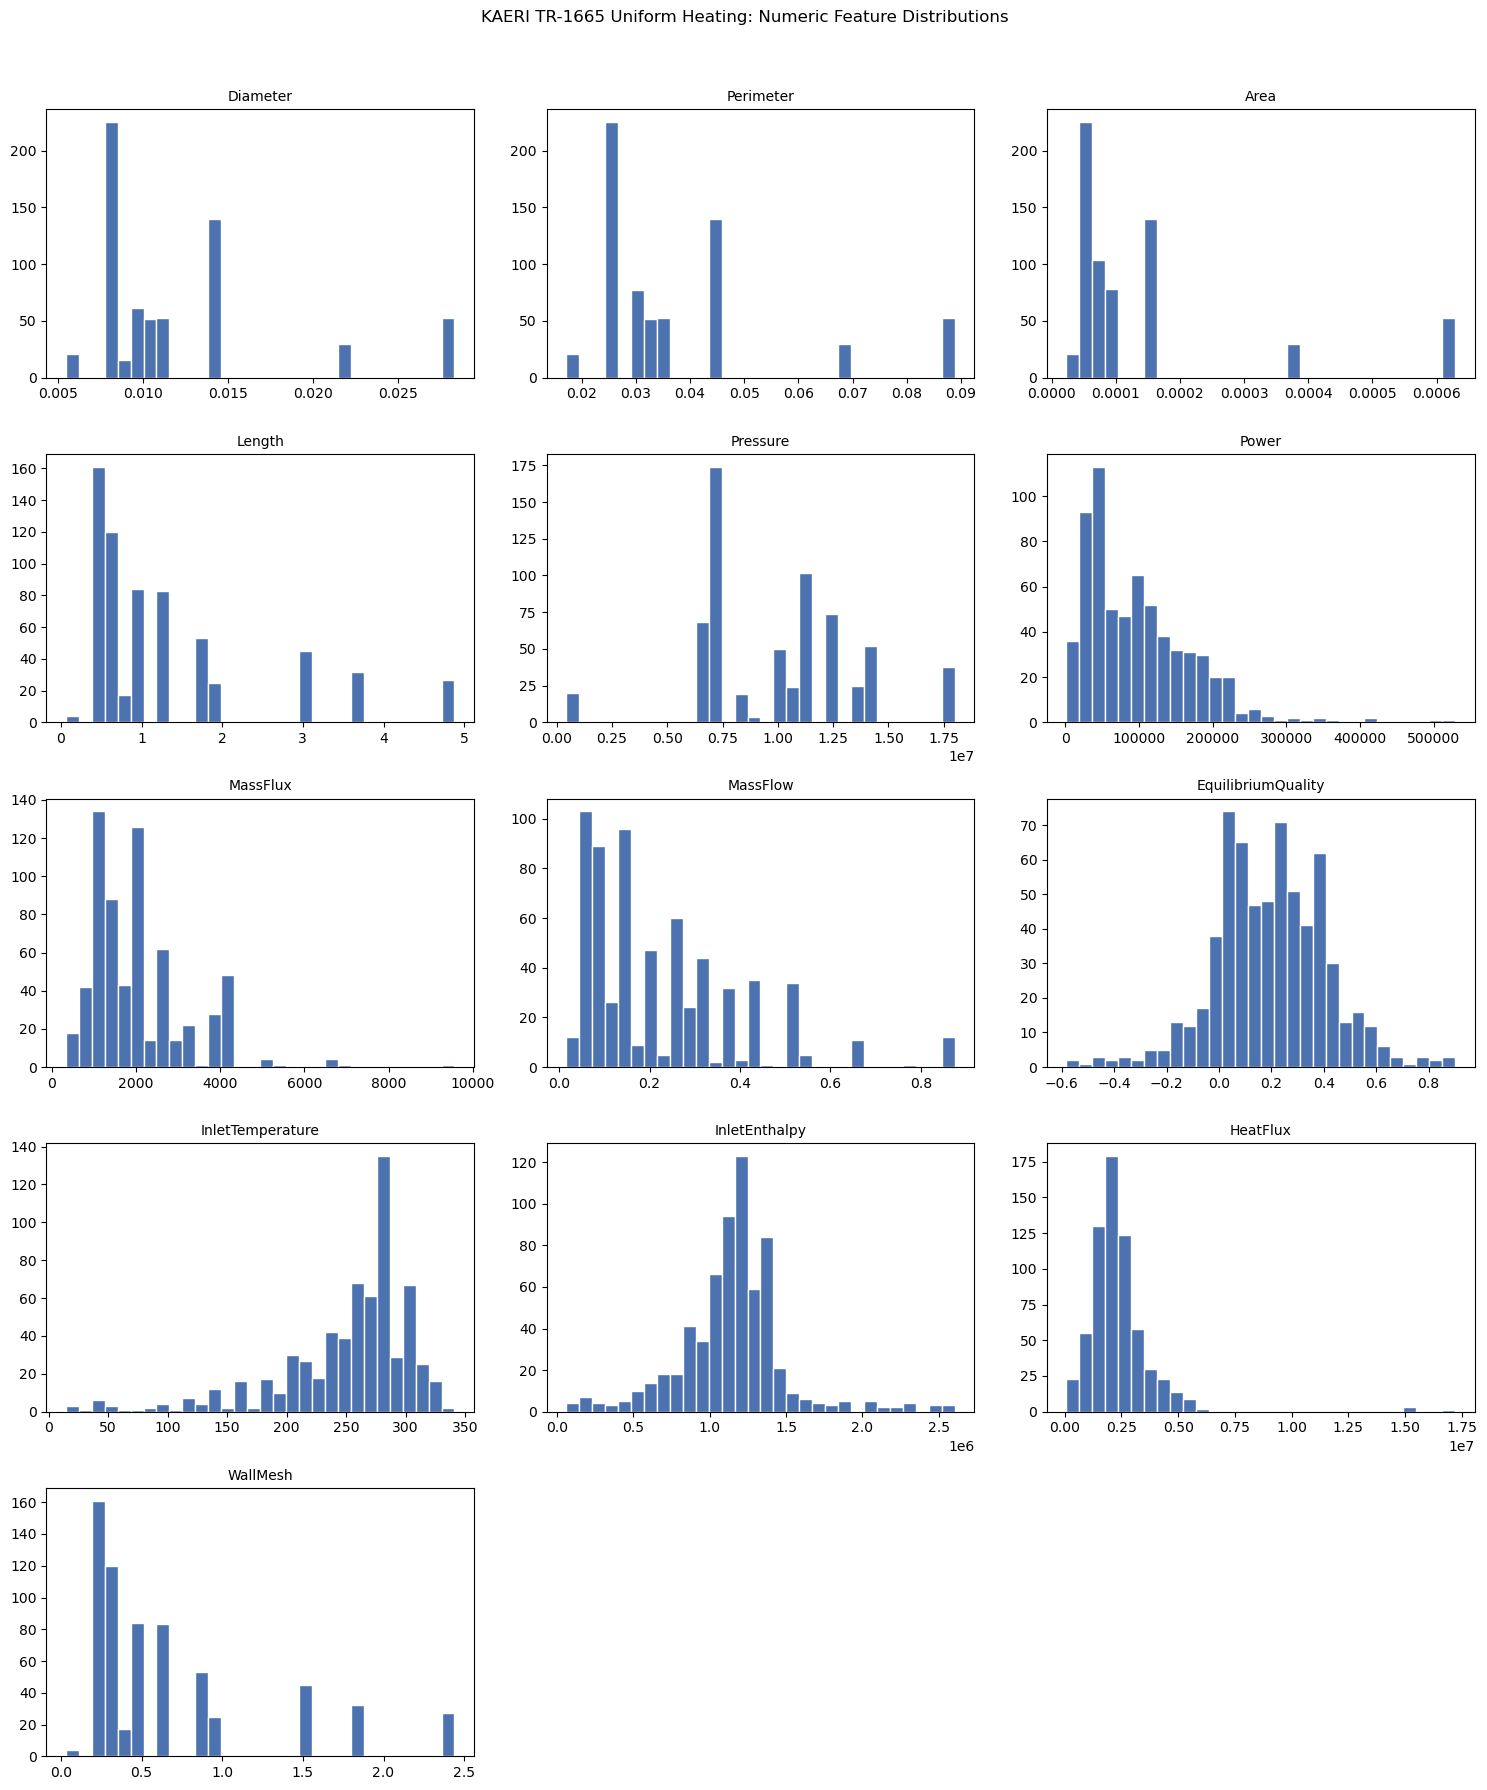

In [6]:
n = len(NUMERIC_COLS)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, NUMERIC_COLS):
    ax.hist(df[col].dropna(), bins=30, color="#4C72B0", edgecolor="white")
    ax.set_title(col, fontsize=10)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: Numeric Feature Distributions", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "histograms.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Outlier Scan (IQR, z-score)

In [7]:
iqr_rows = []
for col in NUMERIC_COLS:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((s < lo) | (s > hi)).sum())
    iqr_rows.append({
        "column": col, "q1": q1, "q3": q3, "iqr": iqr,
        "lower_fence": lo, "upper_fence": hi,
        "n_outliers": n_out, "pct_outliers": 100 * n_out / len(s) if len(s) else np.nan,
    })
iqr_table = pd.DataFrame(iqr_rows).set_index("column")
iqr_table.to_csv(OUT_DIR / "iqr_outlier_summary.csv")
iqr_table

,q1,q3,iqr,lower_fence,upper_fence,n_outliers,pct_outliers
column,,,,,,,
Diameter,7.900000e-03,1.407000e-02,6.170000e-03,-1.355000e-03,2.332500e-02,53,8.141321
Perimeter,2.480000e-02,4.420000e-02,1.940000e-02,-4.300000e-03,7.330000e-02,53,8.141321
Area,4.901700e-05,1.554800e-04,1.064630e-04,-1.106775e-04,3.151745e-04,83,12.749616
Length,5.000000e-01,1.730000e+00,1.230000e+00,-1.345000e+00,3.575000e+00,59,9.062980
Pressure,6.900000e+06,1.241000e+07,5.510000e+06,-1.365000e+06,2.067500e+07,0,0.000000
Power,4.142780e+04,1.397430e+05,9.831518e+04,-1.060450e+05,2.872158e+05,10,1.536098
MassFlux,1.015900e+03,2.703100e+03,1.687200e+03,-1.514900e+03,5.233900e+03,7,1.075269
MassFlow,7.680000e-02,3.157000e-01,2.389000e-01,-2.815500e-01,6.740500e-01,13,1.996928
EquilibriumQuality,5.200000e-02,3.380000e-01,2.860000e-01,-3.770000e-01,7.670000e-01,16,2.457757


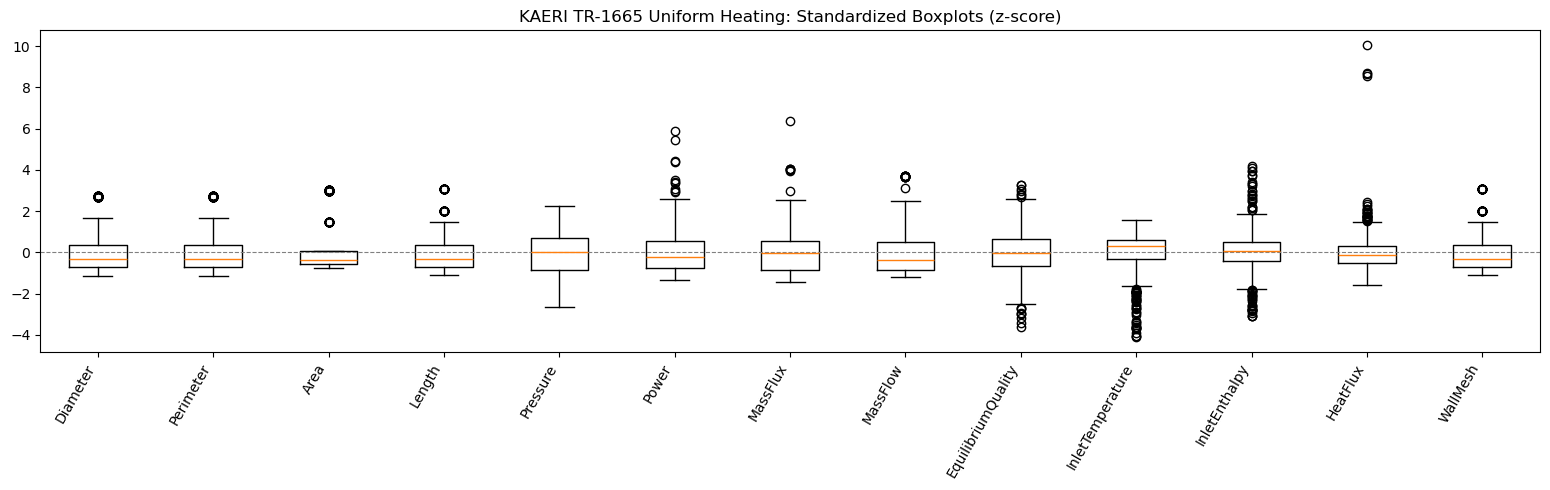

In [8]:
z = df[NUMERIC_COLS].apply(lambda s: (s - s.mean()) / s.std())
fig, ax = plt.subplots(figsize=(max(6, 1.2 * len(NUMERIC_COLS)), 5))
ax.boxplot([z[c].dropna() for c in NUMERIC_COLS])
ax.set_xticklabels(NUMERIC_COLS, rotation=60, ha="right")
ax.set_title(f"{SLUG_TITLE}: Standardized Boxplots (z-score)")
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
fig.tight_layout()
fig.savefig(FIG_DIR / "boxplots_standardized.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Correlation Structure

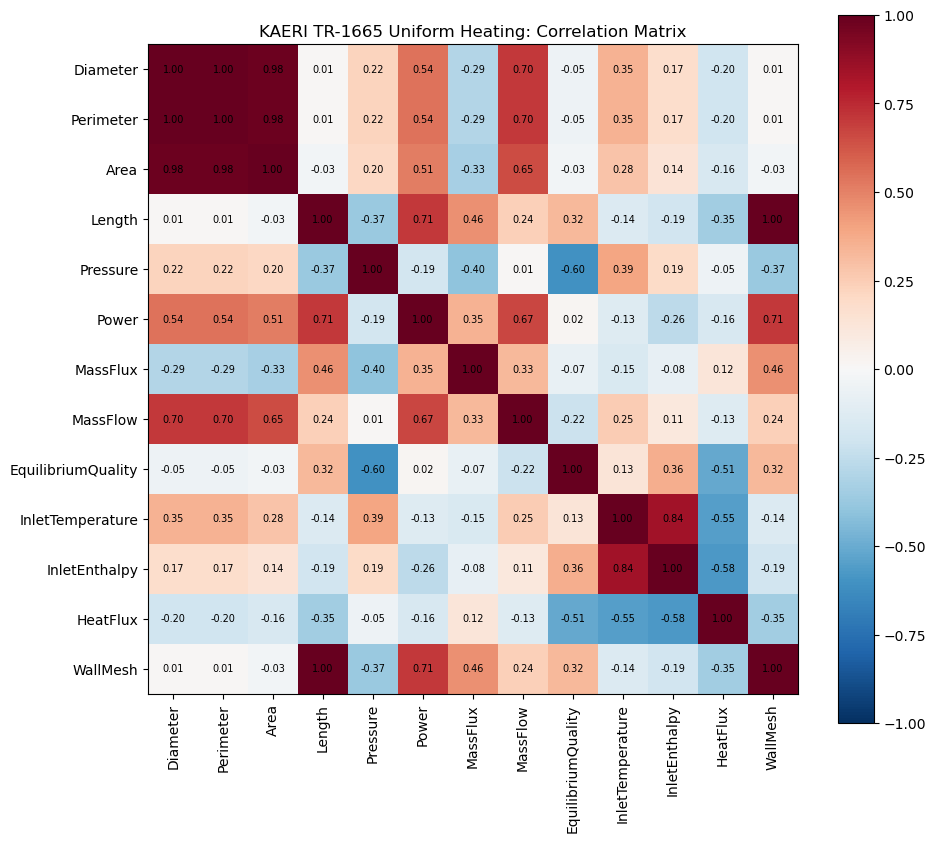

In [9]:
corr = df[NUMERIC_COLS].corr()
corr.to_csv(OUT_DIR / "correlation_matrix.csv")
fig, ax = plt.subplots(figsize=(0.6 * len(NUMERIC_COLS) + 2, 0.6 * len(NUMERIC_COLS) + 2))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(NUMERIC_COLS)))
ax.set_xticklabels(NUMERIC_COLS, rotation=90)
ax.set_yticks(range(len(NUMERIC_COLS)))
ax.set_yticklabels(NUMERIC_COLS)
for i in range(len(NUMERIC_COLS)):
    for j in range(len(NUMERIC_COLS)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)
fig.colorbar(im, shrink=0.8)
ax.set_title(f"{SLUG_TITLE}: Correlation Matrix")
fig.tight_layout()
fig.savefig(FIG_DIR / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Target vs. Features

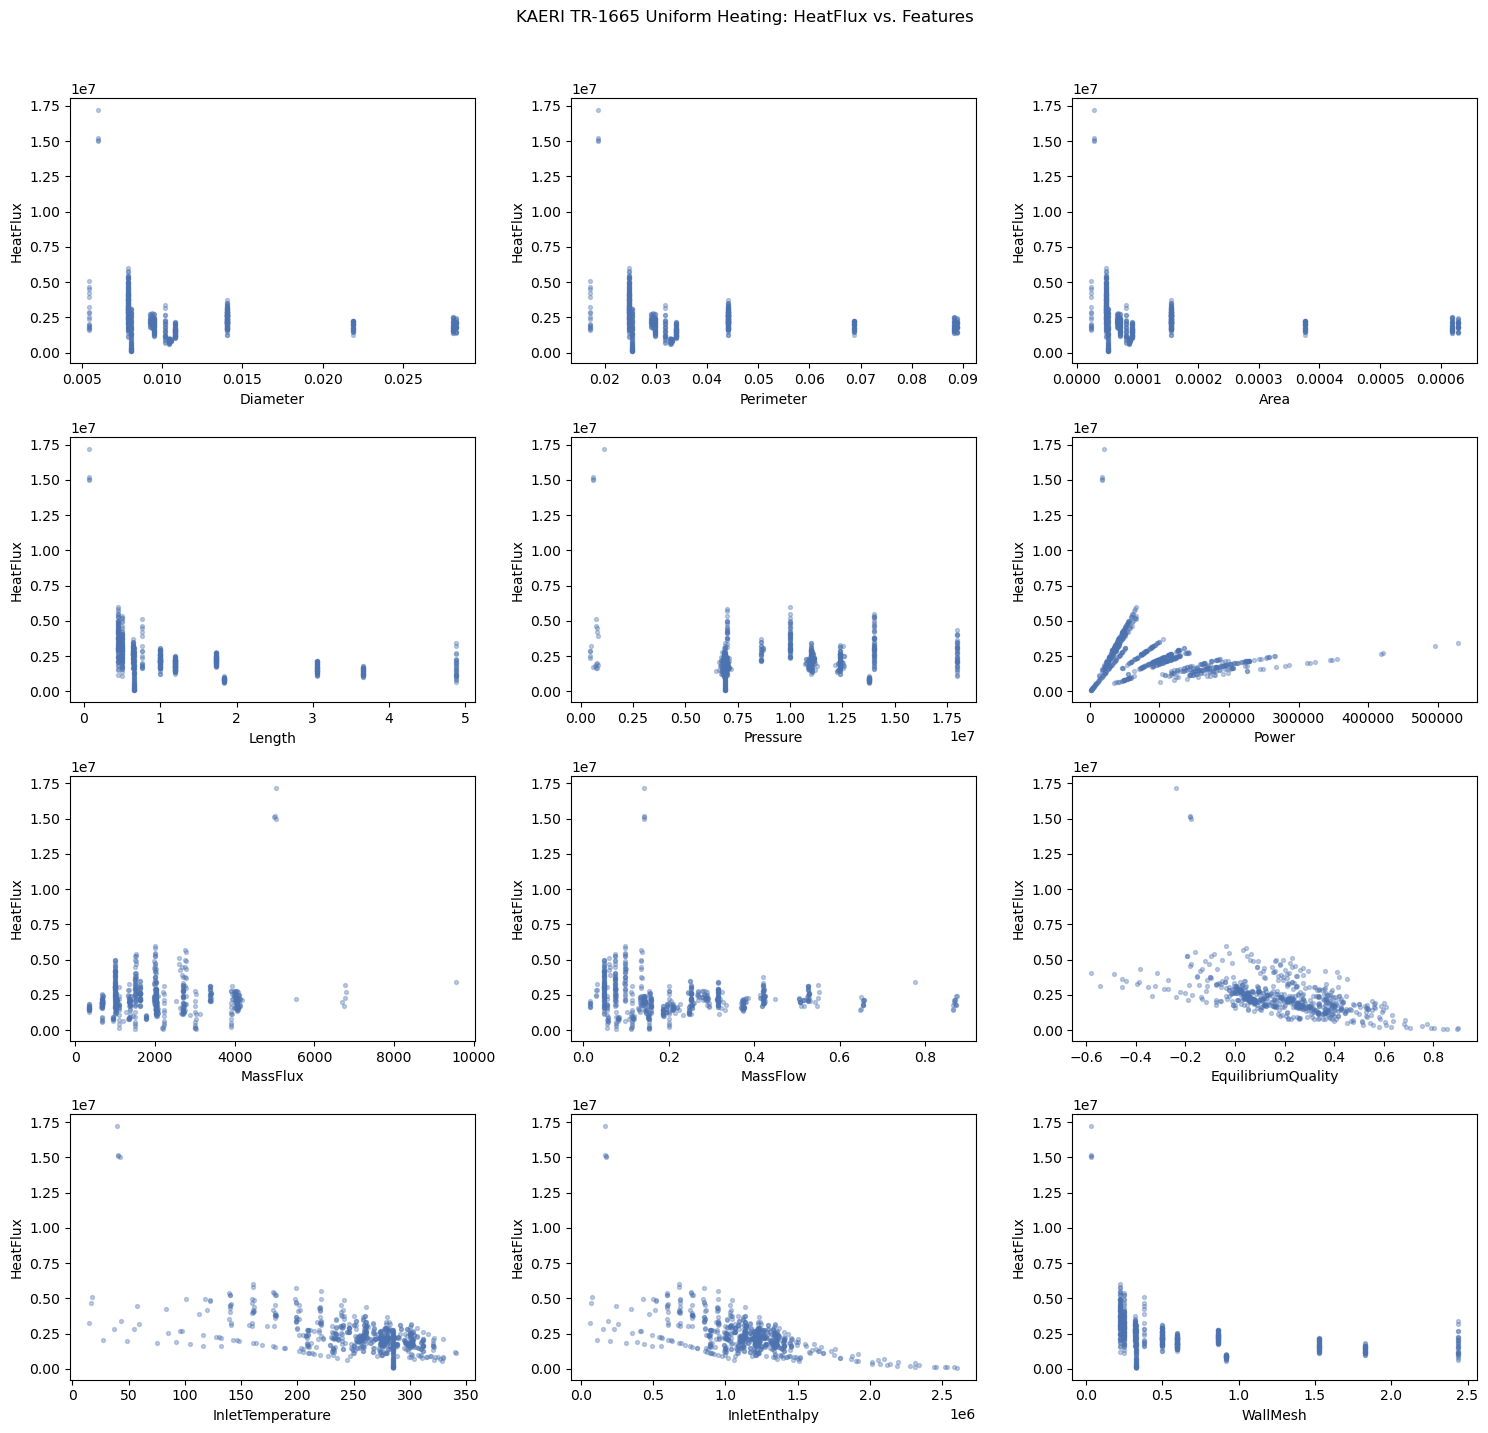

In [10]:
feature_cols = [c for c in NUMERIC_COLS if c != TARGET_COL]
n = len(feature_cols)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)
for ax, col in zip(axes, feature_cols):
    ax.scatter(df[col], df[TARGET_COL], s=8, alpha=0.35, color="#4C72B0")
    ax.set_xlabel(col)
    ax.set_ylabel(TARGET_COL)
for ax in axes[n:]:
    ax.axis("off")
fig.suptitle(f"{SLUG_TITLE}: {TARGET_COL} vs. Features", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "target_vs_features.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Target by Category

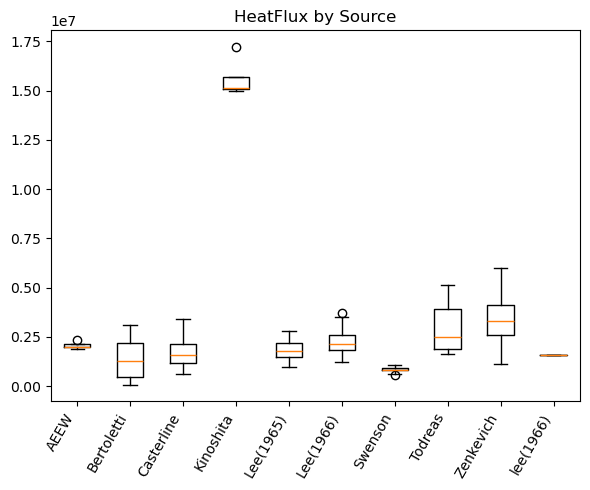

In [11]:
cat_cols_plot = [c for c in CATEGORICAL_COLS
                 if 2 <= df[c].nunique(dropna=True) <= 15]
if cat_cols_plot:
    fig, axes = plt.subplots(1, len(cat_cols_plot), figsize=(6 * len(cat_cols_plot), 5), squeeze=False)
    axes = axes[0]
    for ax, col in zip(axes, cat_cols_plot):
        groups = [g[TARGET_COL].dropna().values for _, g in df.groupby(col)]
        labels = [str(k) for k, _ in df.groupby(col)]
        ax.boxplot(groups)
        ax.set_xticklabels(labels, rotation=60, ha="right")
        ax.set_title(f"{TARGET_COL} by {col}")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "target_by_category.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No low-cardinality categorical columns (2-15 unique values) available for grouped comparison.")


## 10. Takeaways

- The XML source repeats `WallPower`/`WallMesh` tags identically within each
  `<dataset>` block (a serialization quirk, not additional information) — the
  first occurrence matches the CSV exactly.
- `HeatFlux` is used as the CHF target; `EquilibriumQuality` at CHF and
  `MassFlux` are the primary boiling-crisis predictors alongside `Pressure`
  and tube `Diameter`/`Length`.
- All rows are `Fluid = water`, `Source = Swenson` — these columns carry no
  variance in this file and are shown for completeness only.
